In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
housing = fetch_california_housing()
type(housing)

sklearn.utils._bunch.Bunch

In [15]:
X = pd.DataFrame(housing.data, columns = housing.feature_names)
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [16]:
X.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [17]:
y = pd.DataFrame(housing.target, columns=housing.target_names)
y

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


In [22]:
from sklearn.preprocessing import PowerTransformer, FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [19]:
X.shape

(20640, 8)

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=42)
X_train.shape, y_train.shape

((16512, 8), (16512, 1))

In [23]:
l1 = LinearRegression()
l1.fit(X_train,y_train)
y_pred = l1.predict(X_test)
print(mean_squared_error(y_test,y_pred))

0.5558915986952442


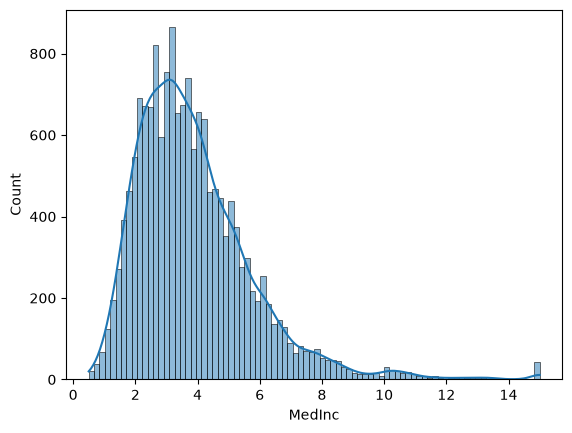

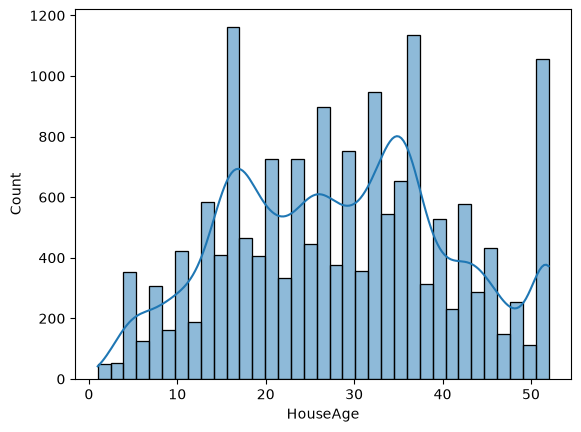

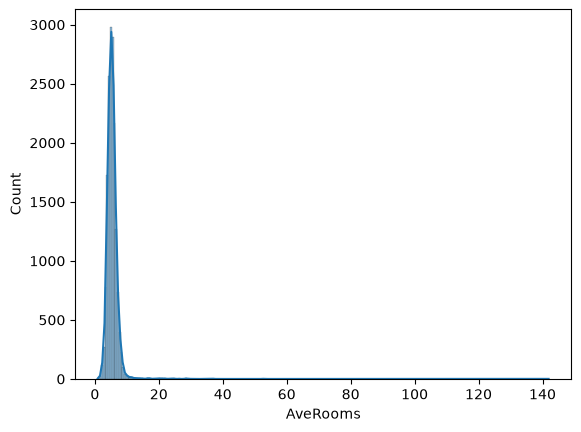

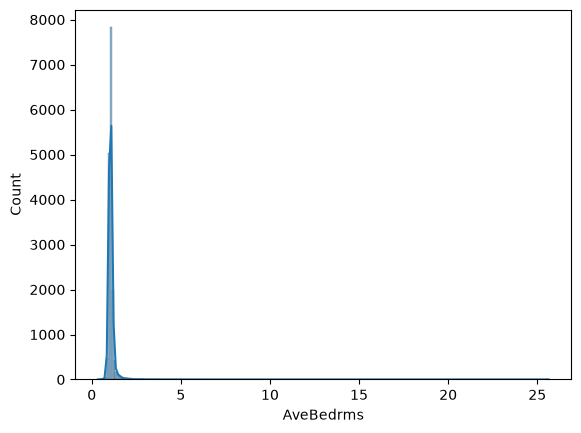

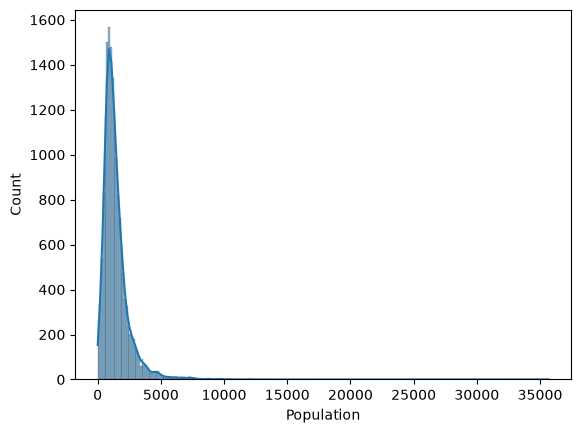

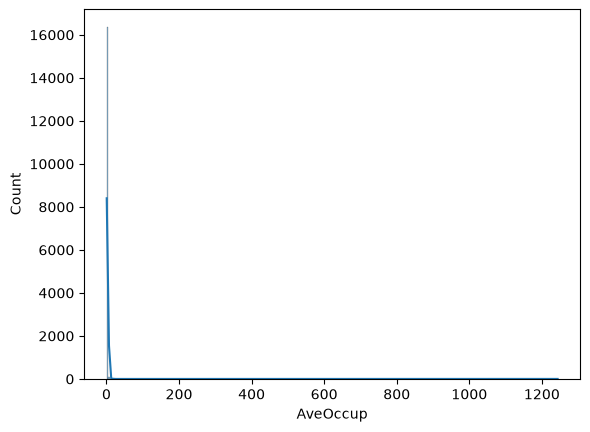

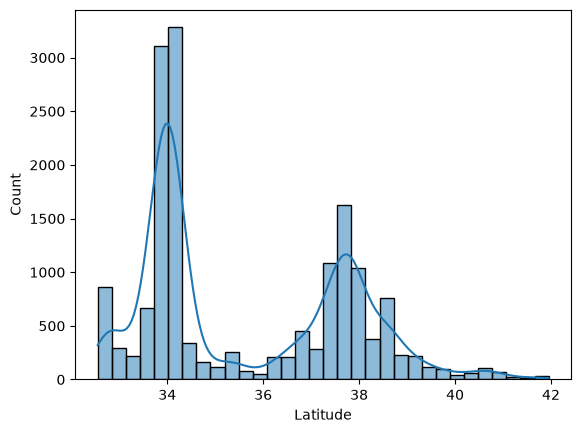

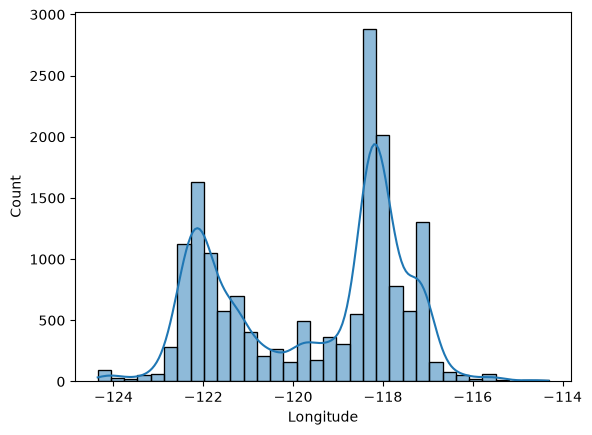

In [29]:
for column in X_train.columns:
    sns.histplot(X_train[column],kde=True)
    plt.show()

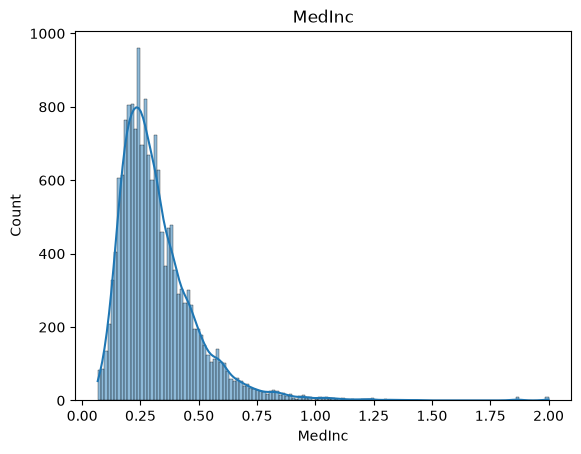

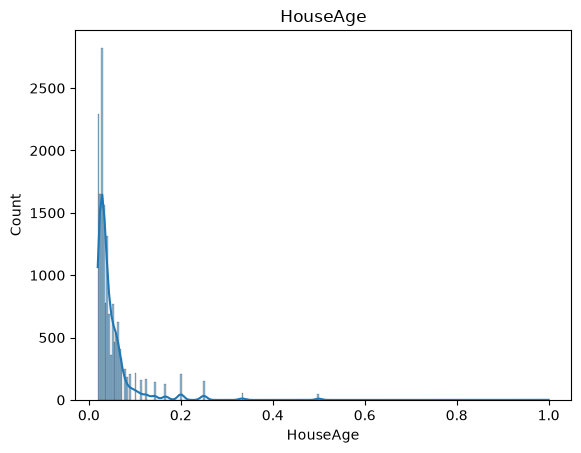

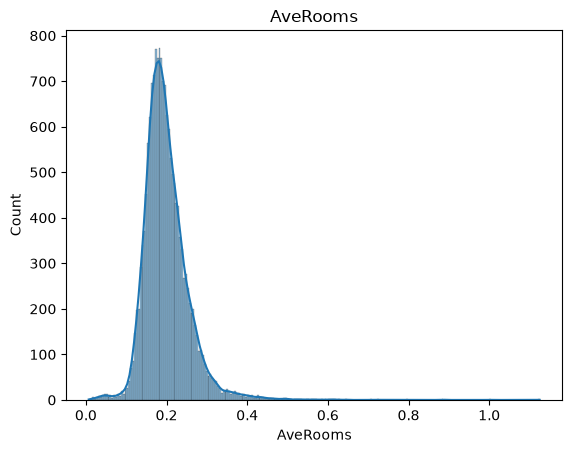

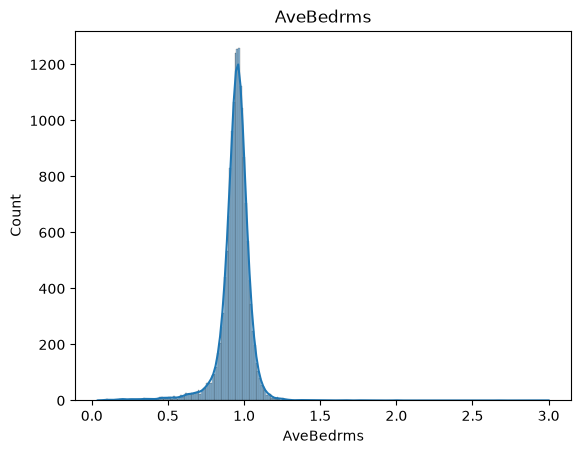

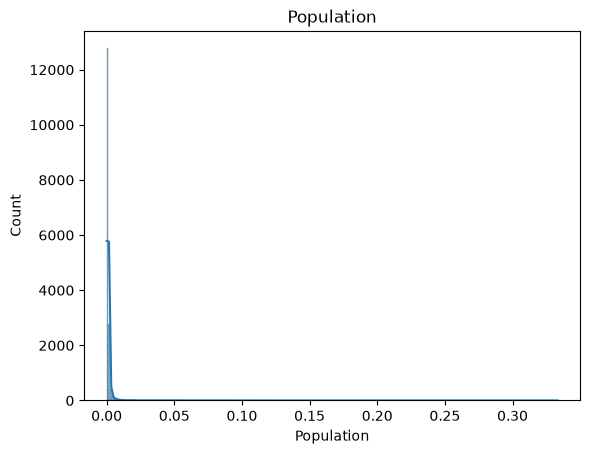

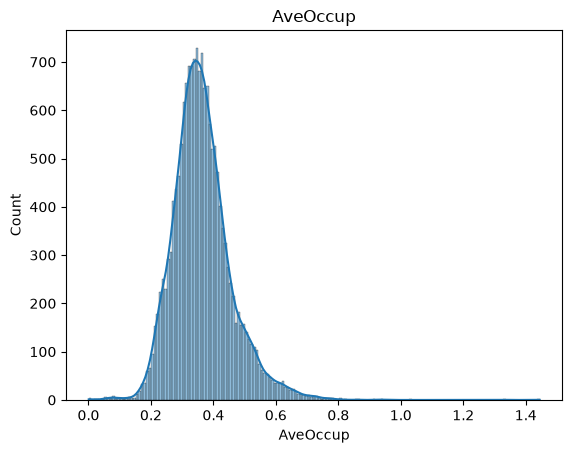

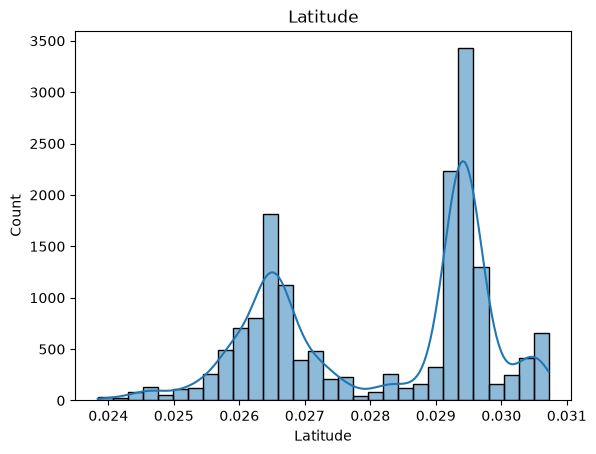

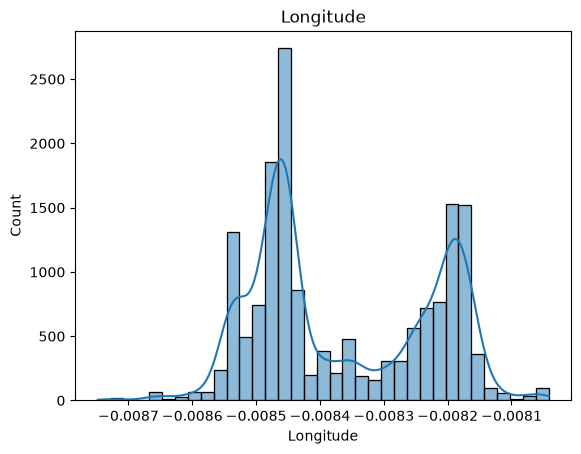

In [32]:
ft = FunctionTransformer(np.reciprocal)

X_train_transformed = pd.DataFrame(
    ft.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

for column in X_train_transformed.columns:
    sns.histplot(X_train_transformed[column], kde=True)
    plt.title(column)
    plt.show()

In [37]:
X_test_transformed = pd.DataFrame(ft.transform(X_test), columns= X_test.columns,index=X_test.index)

In [57]:
lr1 = LinearRegression()
lr1.fit(X_train_transformed,y_train)
y_pred = lr1.predict(X_test_transformed)
print(mean_squared_error(y_test,y_pred))

0.5210633755580167


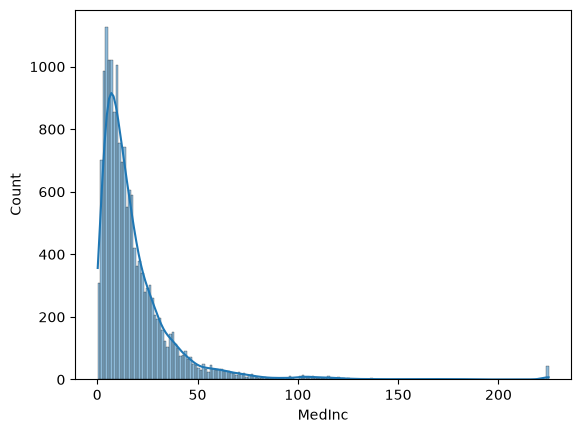

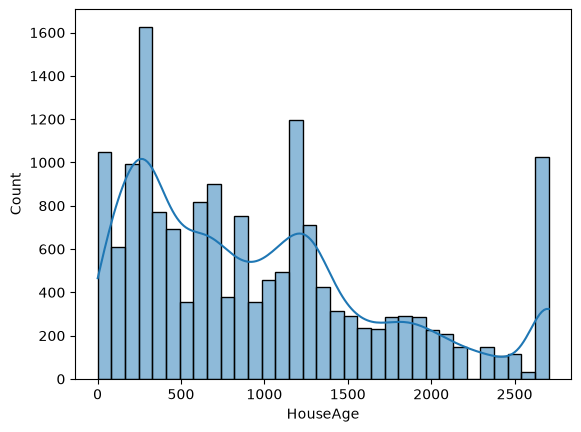

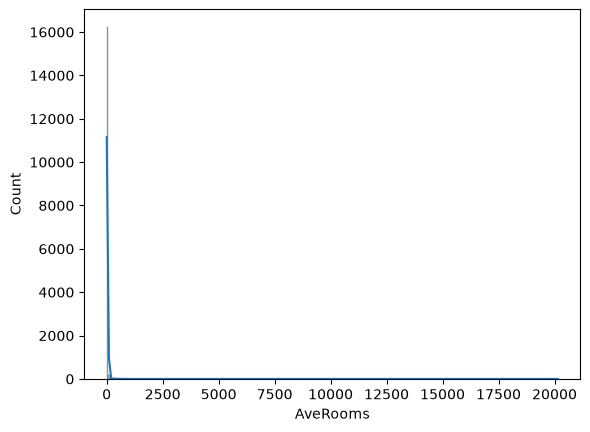

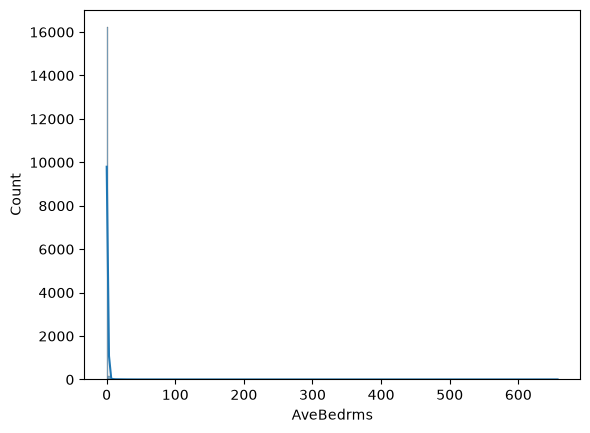

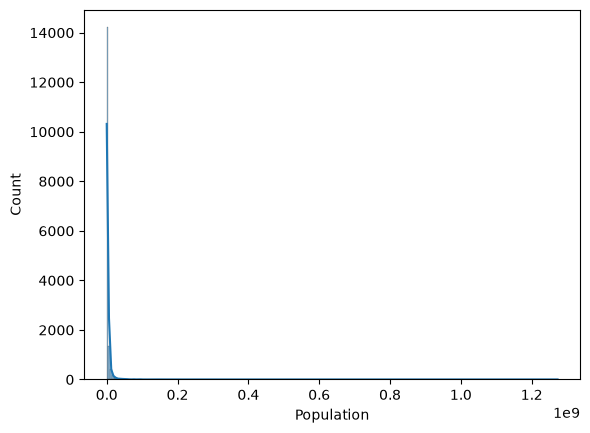

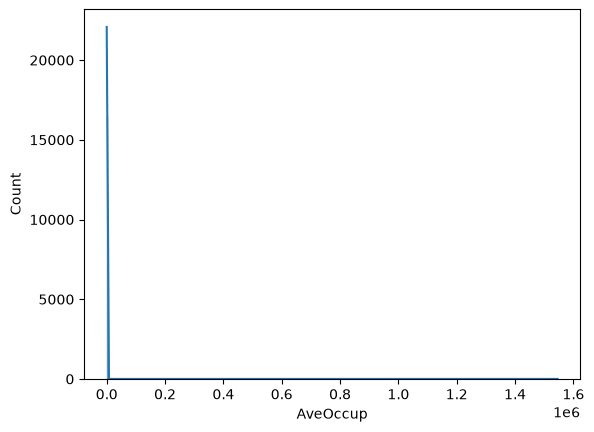

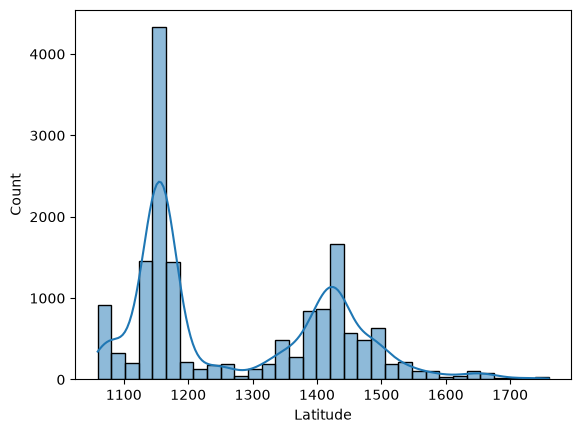

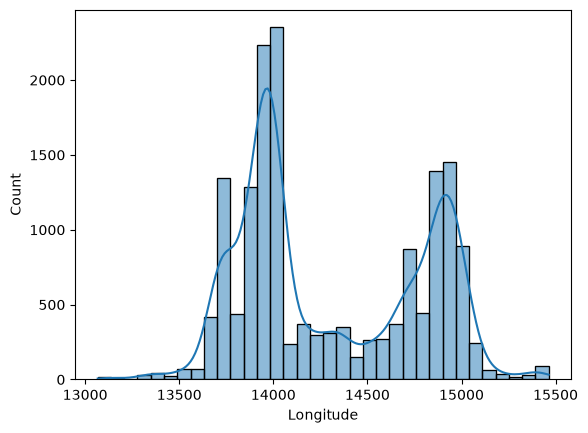

In [35]:
ft1 = FunctionTransformer(np.square)

X_train_transformed = ft1.fit_transform(X_train)
for column in X_train_transformed.columns:
    sns.histplot(X_train_transformed[column], kde=True)
    plt.show()

In [40]:
X_test_transformed = ft1.transform(X_test)
lr2 = LinearRegression()
lr2.fit(X_train_transformed,y_train)
y_pred = lr2.predict(X_test_transformed)
print(mean_squared_error(y_test,y_pred))

0.6216025781338231


In [48]:
print(X_train.columns)

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='str')


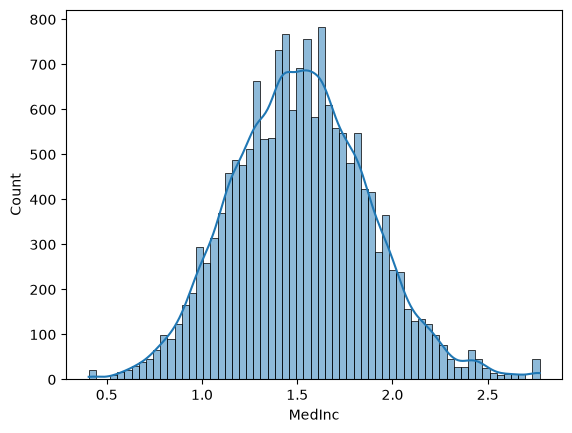

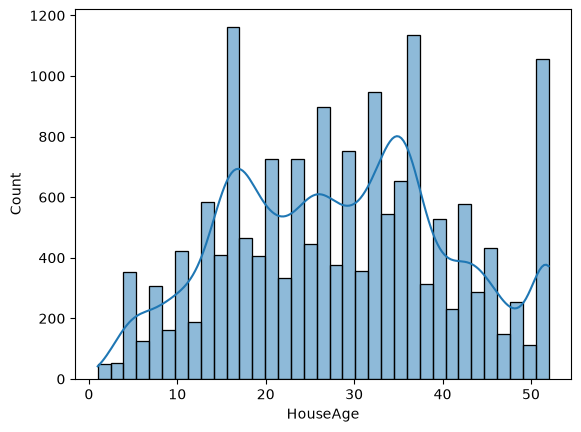

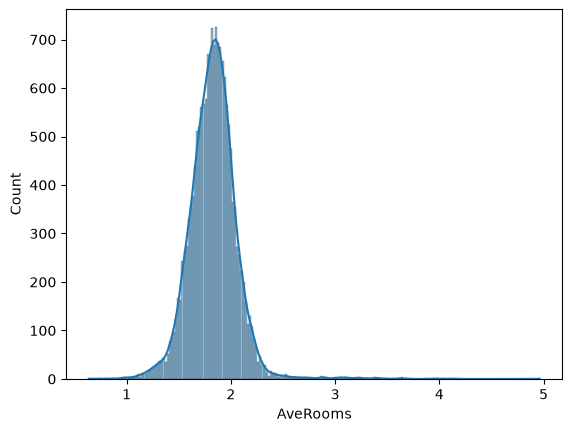

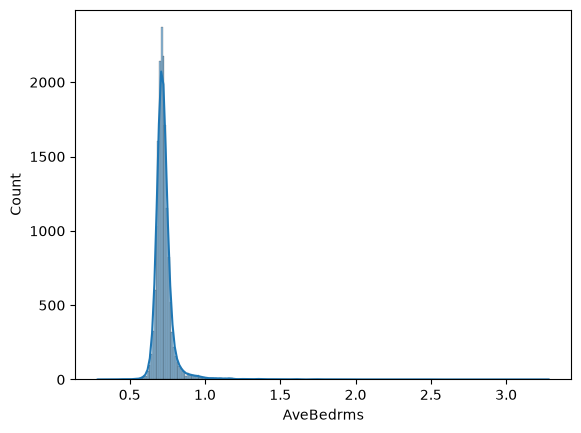

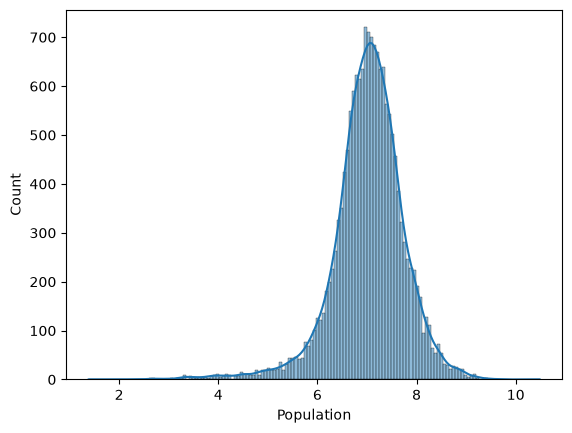

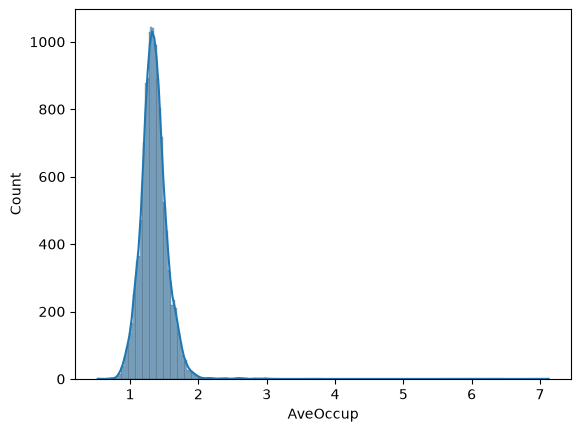

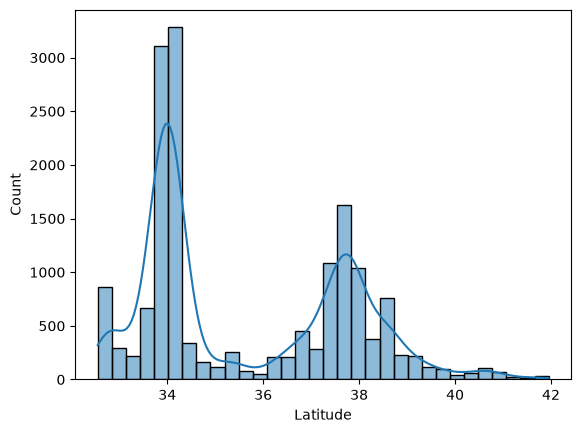

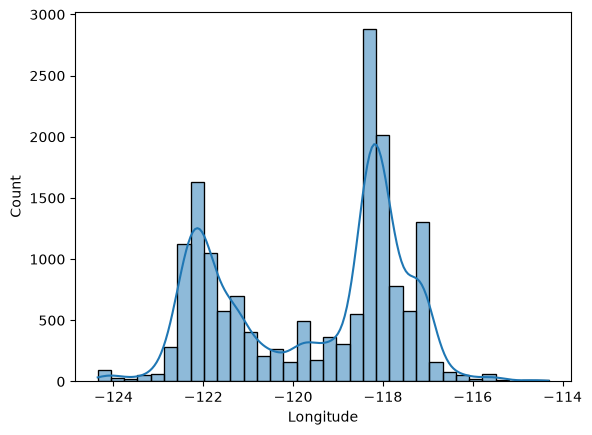

In [49]:
fr3 = FunctionTransformer(np.log1p)
cols = ['MedInc','AveRooms', 'AveBedrms','Population','AveOccup']
X_train_transformed = X_train.copy()
X_train_transformed[cols] = fr3.fit_transform(X_train_transformed[cols])
for column in X_test_transformed.columns:
    sns.histplot(X_train_transformed[column], kde = True)
    plt.show()

In [51]:
X_test_transformed  = X_test.copy()
X_test_transformed[cols] = fr3.transform(X_test_transformed[cols])
lr3 = LinearRegression()
lr3.fit(X_train_transformed,y_train)
y_pred = lr3.predict(X_test_transformed)
print(mean_squared_error(y_test, y_pred))

0.5092479334231447


### boc-cox can only work for strictly positive value

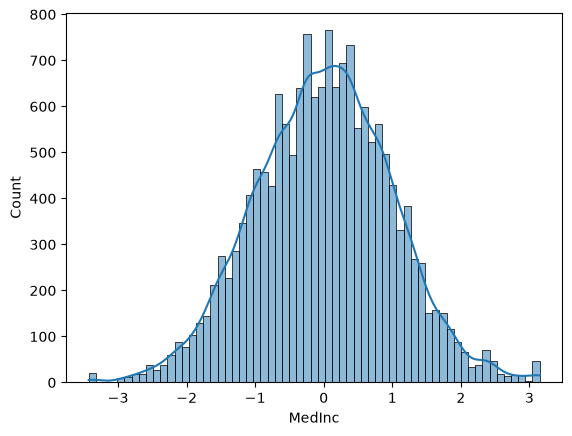

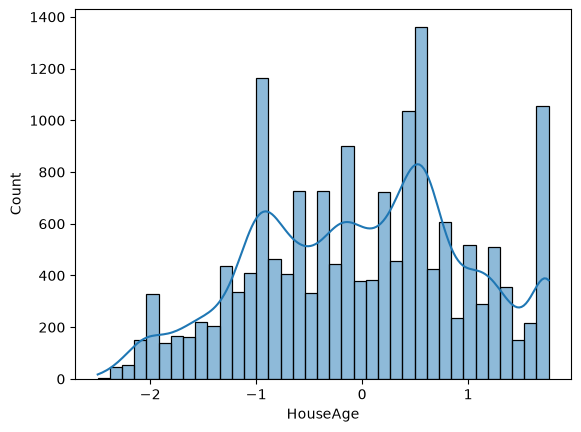

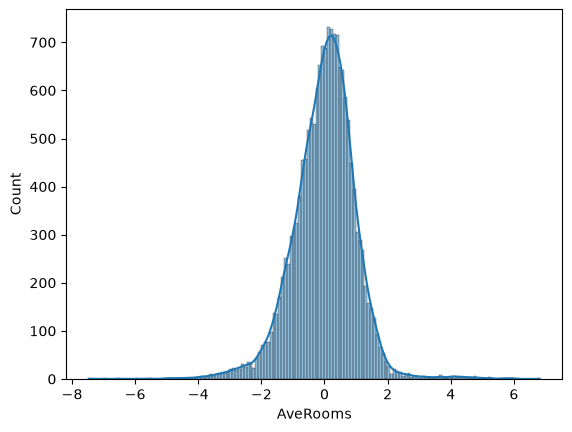

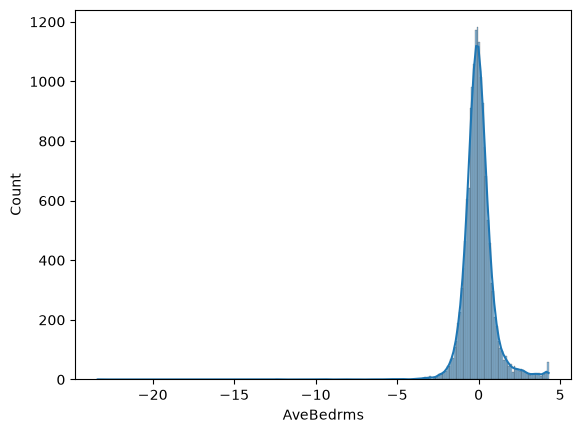

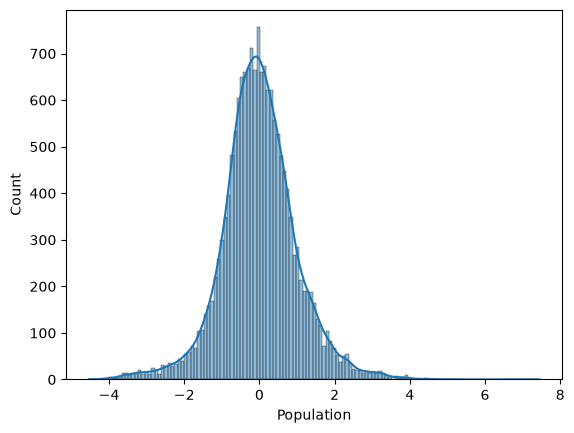

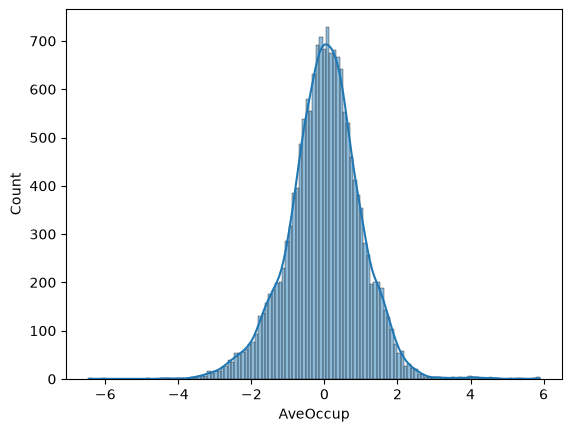

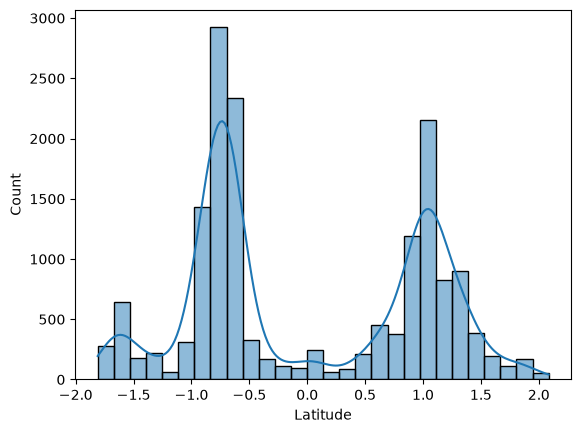

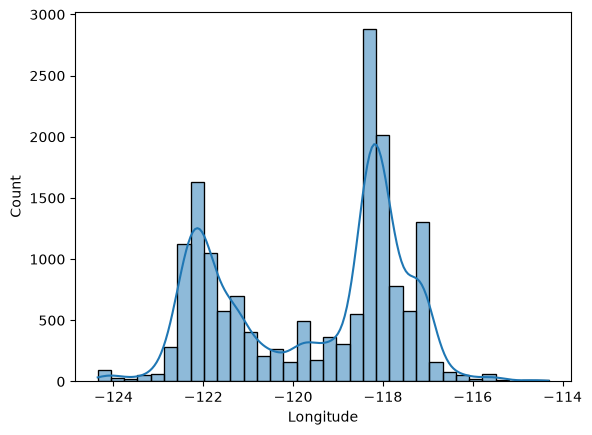

In [55]:
cols = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup','Latitude']
pt1 = PowerTransformer('yeo-johnson')
X_train_transformed = X_train.copy()
X_train_transformed[cols] = pt1.fit_transform(X_train_transformed[cols])
X_test_transformed = X_test.copy()
X_test_transformed[cols] = pt1.transform(X_test_transformed[cols])

for column in X_train_transformed.columns:
    sns.histplot(X_train_transformed[column], kde = True)
    plt.show()

In [56]:
lr4 = LinearRegression()
lr4.fit(X_train_transformed, y_train)
y_pred = lr4.predict(X_test_transformed)
print(mean_squared_error(y_test, y_pred))

0.5210633755580167


The minimum mean was achieved by Log Transform